## Task 2: simple baseline model

Import all the dependencies en setup the Keras backend. You select the backend you want to use and change os.environ based on the availability of a GPU to accelerate computation. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import seaborn as sns
import pandas as pd

In [2]:
import os

# Set Keras backend (can be 'tensorflow', 'torch', 'jax')
os.environ["KERAS_BACKEND"] = "torch"

# CPU only
# os.environ["CUDA_VISIBLE_DEVICES"] = ""

# Specific GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
import keras
from keras import layers, optimizers, losses

In [4]:
print(f"Keras backend: {keras.backend.backend()}")

Keras backend: torch


Load the data from the preprocessing notebook

In [5]:
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")
X_test_no_normalized = np.load("X_test_no_norm.npy")
y_test_no_normalized = np.load("y_test_no_norm.npy")

### Step 1: 

Set up classification and choose metrics to eveluate the classifier. Because the model will be used in a medical context, the metrics
will be adapted to this. We will use:
 - Accuracy
 - Recall
 - Specifity
 - ROC-AUC

### Step 2: 
Build the initial model. The architecture is as follows:

| Layer | Output shape | Description |
|---|---|---|
| Input | 128 × 128 × 1 | Grayscale X-ray image |
| Conv2D(32, 3×3, same) + BN + ReLU | 128 × 128 × 32 | Detect low-level features (edges, gradients) |
| MaxPooling2D(2×2) | 64 × 64 × 32 | Downsample, retain strongest activations |
| Conv2D(64, 3×3, same) + BN + ReLU | 64 × 64 × 64 | Detect mid-level features (textures, shapes) |
| MaxPooling2D(2×2) | 32 × 32 × 64 | Downsample again |
| Conv2D(128, 3×3, same) + BN + ReLU | 32 × 32 × 128 | Detect high-level features (structures, patterns) |
| MaxPooling2D(2×2) | 16 × 16 × 128 | Final spatial compression |
| Flatten | 32768 | Reshape feature maps to 1D vector |
| Dense(256) + ReLU | 256 | Learn combinations of extracted features |
| Dropout(0.5) | 256 | Regularisation, prevent overfitting |
| Dense(1) + Sigmoid | 1 | Output P(disease) for binary classification |

In [6]:
model = keras.Sequential(
    [
        layers.Input(shape=(128, 128, 1)),
        # Block 1: Convolution + Pooling
        layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Block 2: Convolution + Pooling
        layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Block 3: Convolution + Pooling
        layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Flatten
        layers.Flatten(),
        # Classification head
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,129 (16.36 MB)

 Trainable params: 4,287,681 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Step 3: train the model

The training will be done using the **binairy cross entropy** loss function. This function penalyses confident wrong mispredictions. If the model predicts P(disease) = 0.95 and the true label is 0, the log term produceses a large loss. When the model is confidently correct, the loss approaches 0. It pairs good with the sigmoid activation of the last layer in the network. Because this layer squashes the output to the [0,1] interval, the ouput can be interpreted as a probability and in turn can be used in the cross entropy function.

For model evaluation the metrics mentioned in step 1 will be used.

## 

In [7]:
"""Helper function to compile new models with the same settings and architecture"""

def build_model():
    loss = losses.BinaryCrossentropy()
    optimizer = optimizers.Adam(learning_rate=0.0001)
    model = keras.Sequential(
        [
            layers.Input(shape=(128, 128, 1)),
            # Block 1: Convolution + Pooling
            layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            # Block 2: Convolution + Pooling
            layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            # Block 3: Convolution + Pooling
            layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            # Flatten
            layers.Flatten(),
            # Classification head
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
    return model

In [8]:
from keras.callbacks import ReduceLROnPlateau

#callback to reduce learning rate when validation loss plateaus to help convergence
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6, verbose=1
)

In [9]:
keras.backend.clear_session()
model = build_model()
history = model.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=25,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr],
)

Epoch 1/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 29s 310ms/step - accuracy: 0.6300 - loss: 0.7671 - val_accuracy: 0.6038 - val_loss: 0.6712 - learning_rate: 1.0000e-04
Epoch 2/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 266ms/step - accuracy: 0.6707 - loss: 0.6116 - val_accuracy: 0.6101 - val_loss: 0.6571 - learning_rate: 1.0000e-04
Epoch 3/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.6967 - loss: 0.5635 - val_accuracy: 0.6730 - val_loss: 0.6196 - learning_rate: 1.0000e-04
Epoch 4/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 271ms/step - accuracy: 0.7453 - loss: 0.5143 - val_accuracy: 0.7296 - val_loss: 0.5885 - learning_rate: 1.0000e-04
Epoch 5/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 263ms/step - accuracy: 0.7880 - loss: 0.4529 - val_accuracy: 0.7358 - val_loss: 0.5244 - learning_rate: 1.0000e-04
Epoch 6/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 263ms/step - accuracy: 0.8160 - loss: 0.4056 - val_accuracy: 0.7799 - val_loss: 0.4867 - learning_rate: 1.0000e-04
Epoch 7/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 263ms/step - acc

In [10]:
def plot_training_history_with_val(history, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(history.history["accuracy"], label="Train Accuracy")
    ax.plot(history.history["val_accuracy"], label="Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend(loc="lower right")
    return ax

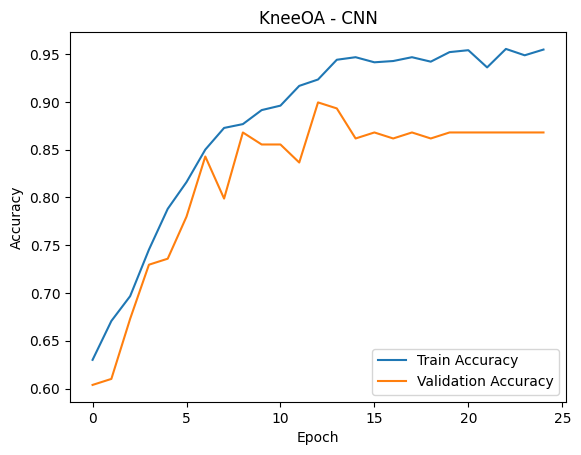

In [11]:
plot_training_history_with_val(history, title="KneeOA - CNN")
plt.show()

### Step 5: Final baseline

In [12]:
X_test = np.concatenate([X_test, X_val])
y_test = np.concatenate([y_test, y_val])

In [13]:
keras.backend.clear_session()
model_final = build_model()
history_final = model_final.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=25,
)

Epoch 1/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy: 0.6307 - loss: 0.7835
Epoch 2/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 230ms/step - accuracy: 0.6813 - loss: 0.6114
Epoch 3/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 240ms/step - accuracy: 0.6860 - loss: 0.5760
Epoch 4/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy: 0.7300 - loss: 0.5320
Epoch 5/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 229ms/step - accuracy: 0.7787 - loss: 0.4740
Epoch 6/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 233ms/step - accuracy: 0.7887 - loss: 0.4322
Epoch 7/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 235ms/step - accuracy: 0.8220 - loss: 0.3923
Epoch 8/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.8407 - loss: 0.3381
Epoch 9/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 252ms/step - accuracy: 0.8487 - loss: 0.3257
Epoch 10/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 252ms/step - accuracy: 0.8820 - loss: 0.2750
Epoch 11/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 252ms/step - accuracy: 0.8793 - loss: 0.2616
Epoch 12/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 25

In [14]:
def plot_training_history(history, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(history.history["accuracy"], label="Train Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend(loc="lower right")
    return ax

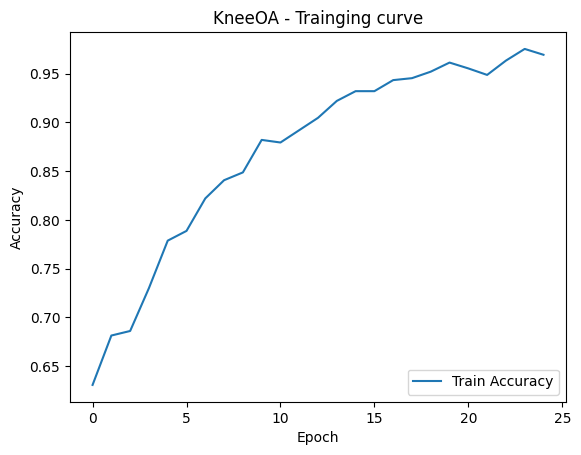

In [15]:
plot_training_history(history_final, title="KneeOA - Trainging curve")
plt.show()

In [17]:
model.save("baseline_model/baseline_final.keras")

I0000 00:00:1776254797.853087   11245 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776254799.294610   11245 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [18]:
test_model = keras.models.load_model("baseline_model/baseline_final.keras")

In [19]:
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, title: str) -> None:
    cnf_matrix = metrics.confusion_matrix(
        y_true, y_pred
    )  # Returns [[TN, FP], [FN, TP]]

    # Rearrange to match [[TP, FP], [FN, TN]]
    rearranged = np.array(
        [
            [cnf_matrix[1, 1], cnf_matrix[0, 1]],  # TP, FP  (row0: Predicted Positive)
            [cnf_matrix[1, 0], cnf_matrix[0, 0]],  # FN, TN  (row1: Predicted Negative)
        ]
    )
    print(title, f'TP={cnf_matrix[1, 1]}', f'FP={cnf_matrix[0, 1]}', f'FN={cnf_matrix[1, 0]}', f'TN={cnf_matrix[0, 0]}' )
    ax = sns.heatmap(
        pd.DataFrame(rearranged), annot=True, cmap="Blues", fmt="g", cbar=False
    )
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Actual", fontsize=12)
    ax.set_ylabel("Predicted", fontsize=12)
    ax.set_xticklabels(["Positive", "Negative"], fontsize=10)
    ax.set_yticklabels(["Positive", "Negative"], fontsize=10)
    plt.tight_layout()
    plt.title(title, fontsize=14, fontweight="bold")
    plt.show()

For evaluation, first we want to look at the accuracy. 

In [20]:
y_pred_prob = test_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(y_pred.shape, y_test.shape)

test_acc = np.mean(y_pred.flatten() == y_test)
print(f"Test Accuracy: {test_acc:.4f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
(305, 1) (305,)
Test Accuracy: 0.8984


For medial data accuracy is not a good metric so use other metrics instead. The fraction of patients that have the disease and actually get diagnosed (recall), and of the patients that dont have the disease and dont get diagnosed (specificity), will give more insight in how the model is actually performing. Recall should be high because false negatives have a high impact on patients lives. On the other side, maximizing specificity will help the healthcare system save resources and prevent unnecessary treatment on patients. 

Recall: 0.8230
Specificity: 0.9427
ROC AUC Score: 0.9424
Baseline model - Confusion Matrix, threshold=0.5 TP=93 FP=11 FN=20 TN=181


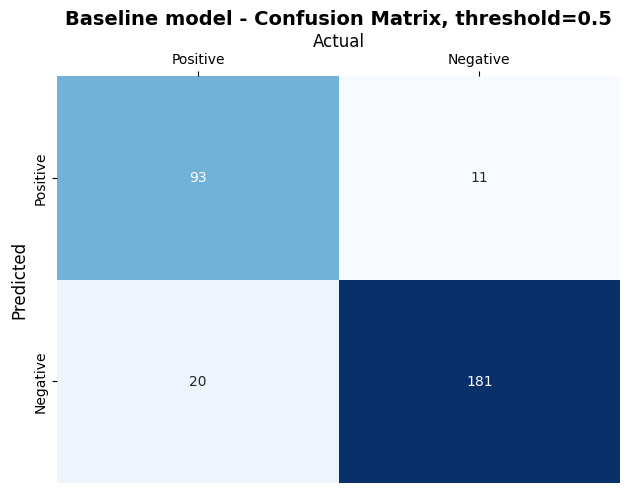

In [21]:
recall_score = metrics.recall_score(y_test, y_pred)
specificity_score = metrics.recall_score(y_test, y_pred, pos_label=0)
roc_auc_score = metrics.roc_auc_score(y_test, y_pred_prob)

print(f"Recall: {recall_score:.4f}")
print(f"Specificity: {specificity_score:.4f}")
print(f"ROC AUC Score: {roc_auc_score:.4f}")
plot_confusion_matrix(y_test, y_pred, title="Baseline model - Confusion Matrix, threshold=0.5")

IndexError: index 186 is out of bounds for axis 0 with size 146

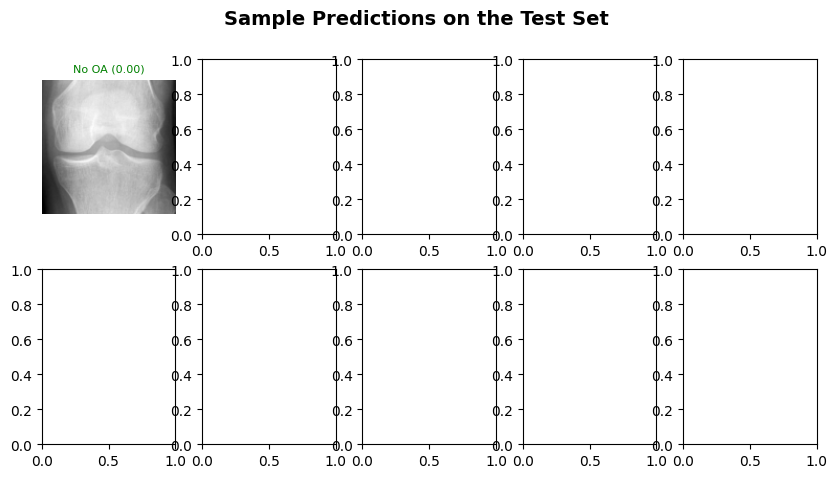

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle("Sample Predictions on the Test Set", fontsize=14, fontweight="bold")
class_names = ["No OA", "OA"]

np.random.seed(42)
for row, label in enumerate([0, 1]):
    indices = np.where(y_test.ravel() == label)[0]
    samples = np.random.choice(indices, size=5, replace=False)
    for col, idx in enumerate(samples):
        pred = y_pred_prob[idx, 0]
        pred_label = int(pred > 0.5)
        correct = pred_label == int(label)
        axes[row, col].imshow(X_test_no_normalized[idx].squeeze(), cmap="gray")
        axes[row, col].axis("off")
        color = "green" if correct else "red"
        axes[row, col].set_title(
            f"{class_names[pred_label]} ({pred:.2f})", fontsize=8, color=color
        )

plt.tight_layout()
plt.show()

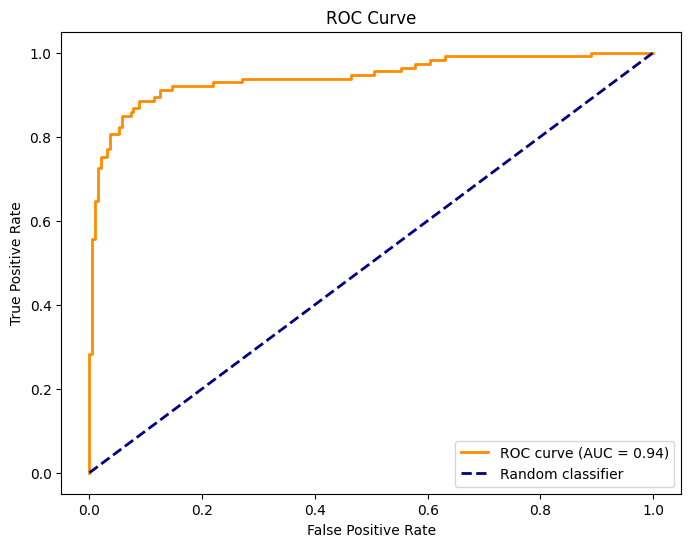

AUC Score: 0.9424


In [23]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob[:, 0])
roc_auc = metrics.auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In the context of knee OA, false negatives are not catastrophic because patients will probably experience pain and will come back for a follow up check. The chance that the disease doesn't get caught at all is fairly low. A false positive can have a higher impact on the patient. It can lead to unnecessary surgery and lifestyle changes. With this reasoning in mind, we aimed for a TPR of about 90%, while keeping FPR as low as possible and chose the optimal threshold accordingly. The following results where obtained: 

In [24]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob[:, 0])

target_tpr = 0.90
valid = np.where(tpr >= target_tpr)[0]

best_idx = valid[np.argmin(fpr[valid])]
best_threshold = thresholds[best_idx]

print(f"Threshold:   {best_threshold:.4f}")
print(f"TPR/Recall:  {tpr[best_idx]:.4f}")
print(f"FPR:         {fpr[best_idx]:.4f}")
print(f"Specificity: {1 - fpr[best_idx]:.4f}")

Threshold:   0.2492
TPR/Recall:  0.9115
FPR:         0.1250
Specificity: 0.8750


Baseline model - Confusion Matrix, threshold=0.2492 TP=102 FP=24 FN=11 TN=168


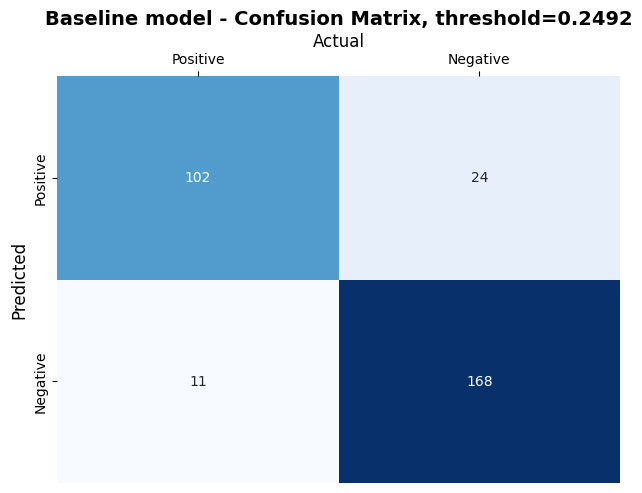

In [25]:
y_pred = (y_pred_prob > best_threshold).astype(int)
plot_confusion_matrix(y_test, y_pred, title=f"Baseline model - Confusion Matrix, threshold={best_threshold:.4f}")

The implications of these results are discussed in the final report. 